# Sales Data Analysis Project

## Import Libraries

In [30]:
import pandas as pd
import numpy as np

## Load Data

In [31]:
data = pd.read_csv("Sales_Data_Project1.csv")
data.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


## Data Cleaning

In [32]:
# Remove unwanted column
data.drop(columns=["Unnamed: 0"], inplace=True)

In [33]:
data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
...,...,...,...,...,...,...,...,...,...,...
185945,222905,AAA Batteries (4-pack),1,2.99,2019-06-07 19:02:00,"795 Pine St, Boston, MA 02215",6,2.99,Boston,19
185946,222906,27in FHD Monitor,1,149.99,2019-06-01 19:29:00,"495 North St, New York City, NY 10001",6,149.99,New York City,19
185947,222907,USB-C Charging Cable,1,11.95,2019-06-22 18:57:00,"319 Ridge St, San Francisco, CA 94016",6,11.95,San Francisco,18
185948,222908,USB-C Charging Cable,1,11.95,2019-06-26 18:35:00,"916 Main St, San Francisco, CA 94016",6,11.95,San Francisco,18


In [34]:
data.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

In [35]:
# Remove duplicates
data.drop_duplicates(inplace=True)

In [36]:
data.dtypes

Order ID              int64
Product              object
Quantity Ordered      int64
Price Each          float64
Order Date           object
Purchase Address     object
Month                 int64
Sales               float64
City                 object
Hour                  int64
dtype: object

In [37]:
# Convert date
data["Order Date"] = pd.to_datetime(data["Order Date"])

### Feature Engineering

In [38]:
data["Month"] = data["Order Date"].dt.month
data["Hour"] = data["Order Date"].dt.hour

In [39]:
data.dtypes

Order ID                     int64
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
Month                        int32
Sales                      float64
City                        object
Hour                         int32
dtype: object

In [40]:
data["Sales"] = data["Quantity Ordered"] * data["Price Each"]

# Analysis

## Monthly Sales

In [41]:
data.groupby("Month")["Sales"].sum().sort_values(ascending=False)

Month
12    4608295.70
10    3734777.86
4     3389217.98
11    3197875.05
5     3150616.23
3     2804973.35
7     2646461.32
6     2576280.15
8     2241083.37
2     2200078.08
9     2094465.69
1     1821413.16
Name: Sales, dtype: float64

## Monthly Sales

In [42]:
data.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)

Product
AAA Batteries (4-pack)        30986
AA Batteries (4-pack)         27615
USB-C Charging Cable          23931
Lightning Charging Cable      23169
Wired Headphones              20524
Apple Airpods Headphones      15637
Bose SoundSport Headphones    13430
27in FHD Monitor               7541
iPhone                         6847
27in 4K Gaming Monitor         6239
34in Ultrawide Monitor         6192
Google Phone                   5529
Flatscreen TV                  4813
Macbook Pro Laptop             4725
ThinkPad Laptop                4128
20in Monitor                   4126
Vareebadd Phone                2068
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int64

## City Sales

In [43]:
data.groupby("City")["Sales"].sum().sort_values(ascending=False)

City
 San Francisco    8254743.55
 Los Angeles      5448304.28
 New York City    4661867.14
 Boston           3658627.65
 Atlanta          2794199.07
 Dallas           2765373.96
 Seattle          2745046.02
 Portland         2319331.94
 Austin           1818044.33
Name: Sales, dtype: float64

## Hourly Sales

In [52]:
data.groupby("Hour")["Sales"].sum()

Hour
0      713548.66
1      460563.90
2      234839.45
3      145742.94
4      162546.07
5      230664.87
6      447963.01
7      744067.32
8     1192309.20
9     1638784.04
10    1942988.08
11    2296619.84
12    2314359.85
13    2152369.98
14    2082513.70
15    1940623.20
16    1902523.20
17    2126553.97
18    2218374.01
19    2411971.14
20    2280784.36
21    2040790.48
22    1606243.85
23    1177792.82
Name: Sales, dtype: float64

# Visualization

## Monthly

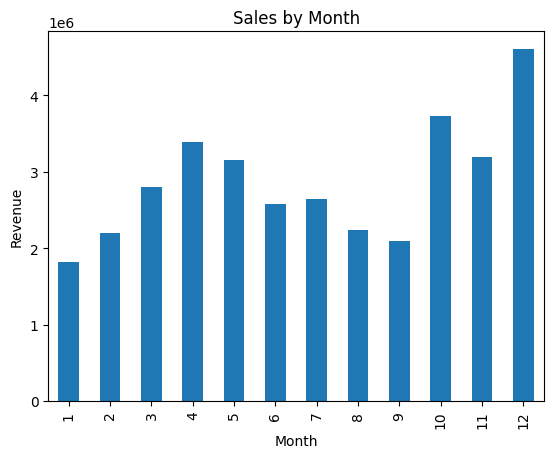

In [45]:
import matplotlib.pyplot as plt

data.groupby("Month")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## City

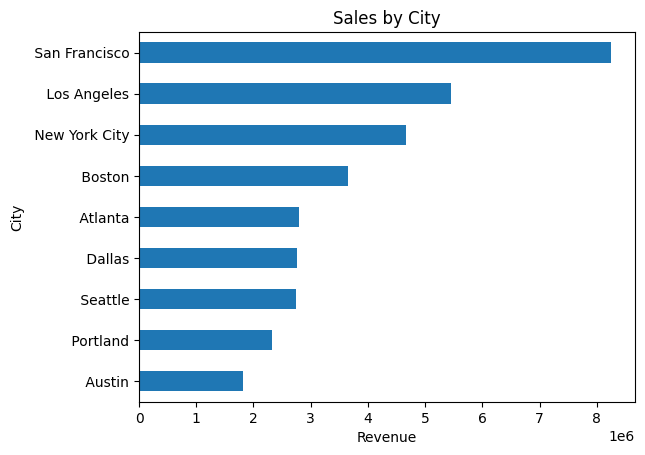

In [46]:
data.groupby("City")["Sales"].sum().sort_values().plot(kind="barh")
plt.title("Sales by City")
plt.xlabel("Revenue")
plt.show()

## Hour

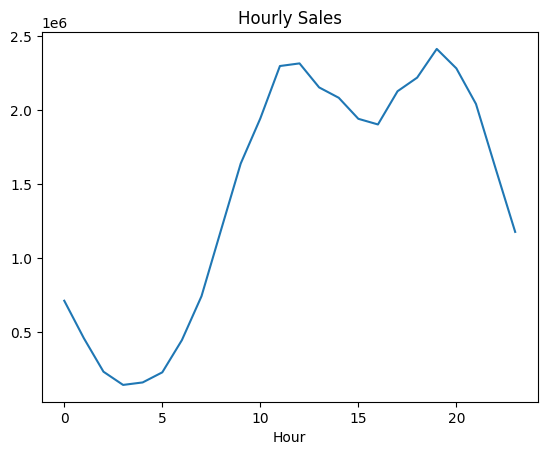

In [56]:
hourly_sales = data.groupby("Hour")["Sales"].sum()
hourly_sales.plot()
plt.title("Hourly Sales")
plt.show()

# Insights

* December has highest sales
* San Francisco is top performing city
* Peak sales time is around 7 PM
* Early morning hours have lowest sales